# Denoising Pipeline

This notebook trains and evaluates multiple neural network architectures (MLP, 1D CNN, 1D UNet) and preprocessing strategies (Standard, MinMax, LogMinMax) for denoising X-ray Fluorescence (XRF) spectra.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import numpy as np
import matplotlib.pyplot as plt
import torch
from src.data.denoising.generator import DenoisingDataGenerator
from src.data.common.base_generator import GeneratorConfig
from src.models.denoising.preprocessing import StandardScaler, MinMaxScaler, LogMinMaxScaler
from src.models.denoising.architectures import MLPAutoencoder, CNNAutoencoder, UNet1D
from src.models.denoising.trainer import DenoisingTrainer

np.random.seed(42)
torch.manual_seed(42)

## 0. Hardware Check
Let's check if a GPU is available and which one is being used.

In [2]:
print(f"PyTorch version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("No GPU detected. Training will proceed on CPU (this may be slow).")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060
GPU Memory: 7.61 GB


## 1. Data Generation
We generate 2000 paired samples using the `DenoisingDataGenerator`. The config is set to generate highly noisy inputs.

In [3]:
generator = DenoisingDataGenerator()
config = GeneratorConfig.Presets.denoising()

num_samples = 2000
noisy_data, clean_data = generator.generate_dataset(num_samples=num_samples, config=config, num_workers=12)

print(f"Generated data shape: {noisy_data.shape}")

Starting parallel generation with 12 workers...


Parallel Generation: 100%|██████████| 2000/2000 [02:42<00:00, 12.34it/s]


Generated data shape: (2000, 600)


## 2. Train / Val / Test Split
We split the data 70/15/15.

In [4]:
indices = np.arange(num_samples)
np.random.shuffle(indices)
noisy_data = noisy_data[indices]
clean_data = clean_data[indices]

train_split = int(0.7 * num_samples)
val_split = int(0.85 * num_samples)

X_train_noisy, y_train_clean = noisy_data[:train_split], clean_data[:train_split]
X_val_noisy, y_val_clean = noisy_data[train_split:val_split], clean_data[train_split:val_split]
X_test_noisy, y_test_clean = noisy_data[val_split:], clean_data[val_split:]

print(f"Train size: {X_train_noisy.shape[0]}")
print(f"Val size: {X_val_noisy.shape[0]}")
print(f"Test size: {X_test_noisy.shape[0]}")

Train size: 1400
Val size: 300
Test size: 300


## 3. Experimental Grid & Training
We loop through our defined preprocessing strategies and architectures, training a model for each combination.

In [5]:
preprocessing_strategies = {
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'LogMinMax': LogMinMaxScaler()
}

architectures = {
    'MLP': MLPAutoencoder,
    'CNN': CNNAutoencoder,
    'UNet': UNet1D
}

results = {}
trained_models = {}

In [6]:
epochs = 150
batch_size = 64
input_dim = noisy_data.shape[1]

for prep_name, scaler in preprocessing_strategies.items():
    print(f"\n{'='*40}")
    print(f"Preprocessing Strategy: {prep_name}")
    print(f"{'='*40}")
    
    # 1. Apply Scaler (fit on clean train data, transform all)
    scaler.fit(y_train_clean)
    
    X_train_scaled = scaler.transform(X_train_noisy)
    y_train_scaled = scaler.transform(y_train_clean)
    
    X_val_scaled = scaler.transform(X_val_noisy)
    y_val_scaled = scaler.transform(y_val_clean)
    
    X_test_scaled = scaler.transform(X_test_noisy)
    y_test_scaled = scaler.transform(y_test_clean)
    
    for arch_name, ArchClass in architectures.items():
        print(f"\n--> Training Model: {arch_name}")
        
        # Initialize model
        model = ArchClass(input_dim=input_dim)
        trainer = DenoisingTrainer(model=model, learning_rate=1e-3)
        
        # Train
        history = trainer.train(
            X_train_scaled, y_train_scaled,
            X_val_scaled, y_val_scaled,
            epochs=epochs,
            batch_size=batch_size
        )
        
        # Evaluate on TEST set in SCALED space
        metrics_scaled = trainer.evaluate_metrics(X_test_scaled, y_test_scaled)
        
        # Evaluate on TEST set in ORIGINAL space
        preds_scaled = trainer.predict(X_test_scaled)
        preds_original = scaler.inverse_transform(preds_scaled)
        
        mse_orig = np.mean((preds_original - y_test_clean)**2)
        mae_orig = np.mean(np.abs(preds_original - y_test_clean))
        
        results[f"{prep_name}_{arch_name}"] = {
            'mse_scaled': metrics_scaled['MSE'],
            'mae_scaled': metrics_scaled['MAE'],
            'mse_orig': mse_orig,
            'mae_orig': mae_orig,
            'history': history
        }
        
        # Store trainer and scaler for final plots
        trained_models[f"{prep_name}_{arch_name}"] = (trainer, scaler)
        
        print(f"Test MSE (Original Scale): {mse_orig:.2e} | MAE: {mae_orig:.2e}")


Preprocessing Strategy: Standard

--> Training Model: MLP
Epoch 30/150 - Train Loss: 1.000000 - Val Loss: 1.649941
Epoch 60/150 - Train Loss: 1.000000 - Val Loss: 1.649941
Epoch 90/150 - Train Loss: 1.000000 - Val Loss: 1.649941
Epoch 120/150 - Train Loss: 1.000000 - Val Loss: 1.649941
Epoch 150/150 - Train Loss: 0.973425 - Val Loss: 1.621614
Test MSE (Original Scale): 1.03e-04 | MAE: 2.62e-03

--> Training Model: CNN
Epoch 30/150 - Train Loss: 0.817662 - Val Loss: 1.453529
Epoch 60/150 - Train Loss: 0.815474 - Val Loss: 1.452043
Epoch 90/150 - Train Loss: 0.812135 - Val Loss: 1.451819
Epoch 120/150 - Train Loss: 0.809186 - Val Loss: 1.452525
Epoch 150/150 - Train Loss: 0.806057 - Val Loss: 1.452377
Test MSE (Original Scale): 7.63e-05 | MAE: 2.37e-03

--> Training Model: UNet
Epoch 30/150 - Train Loss: 0.791492 - Val Loss: 1.467187
Epoch 60/150 - Train Loss: 0.770067 - Val Loss: 1.478609
Epoch 90/150 - Train Loss: 0.758951 - Val Loss: 1.477591
Epoch 120/150 - Train Loss: 0.756313 - Va

## 4. Evaluation & Visualization
Let's compare the reconstructions visually for a single test sample.

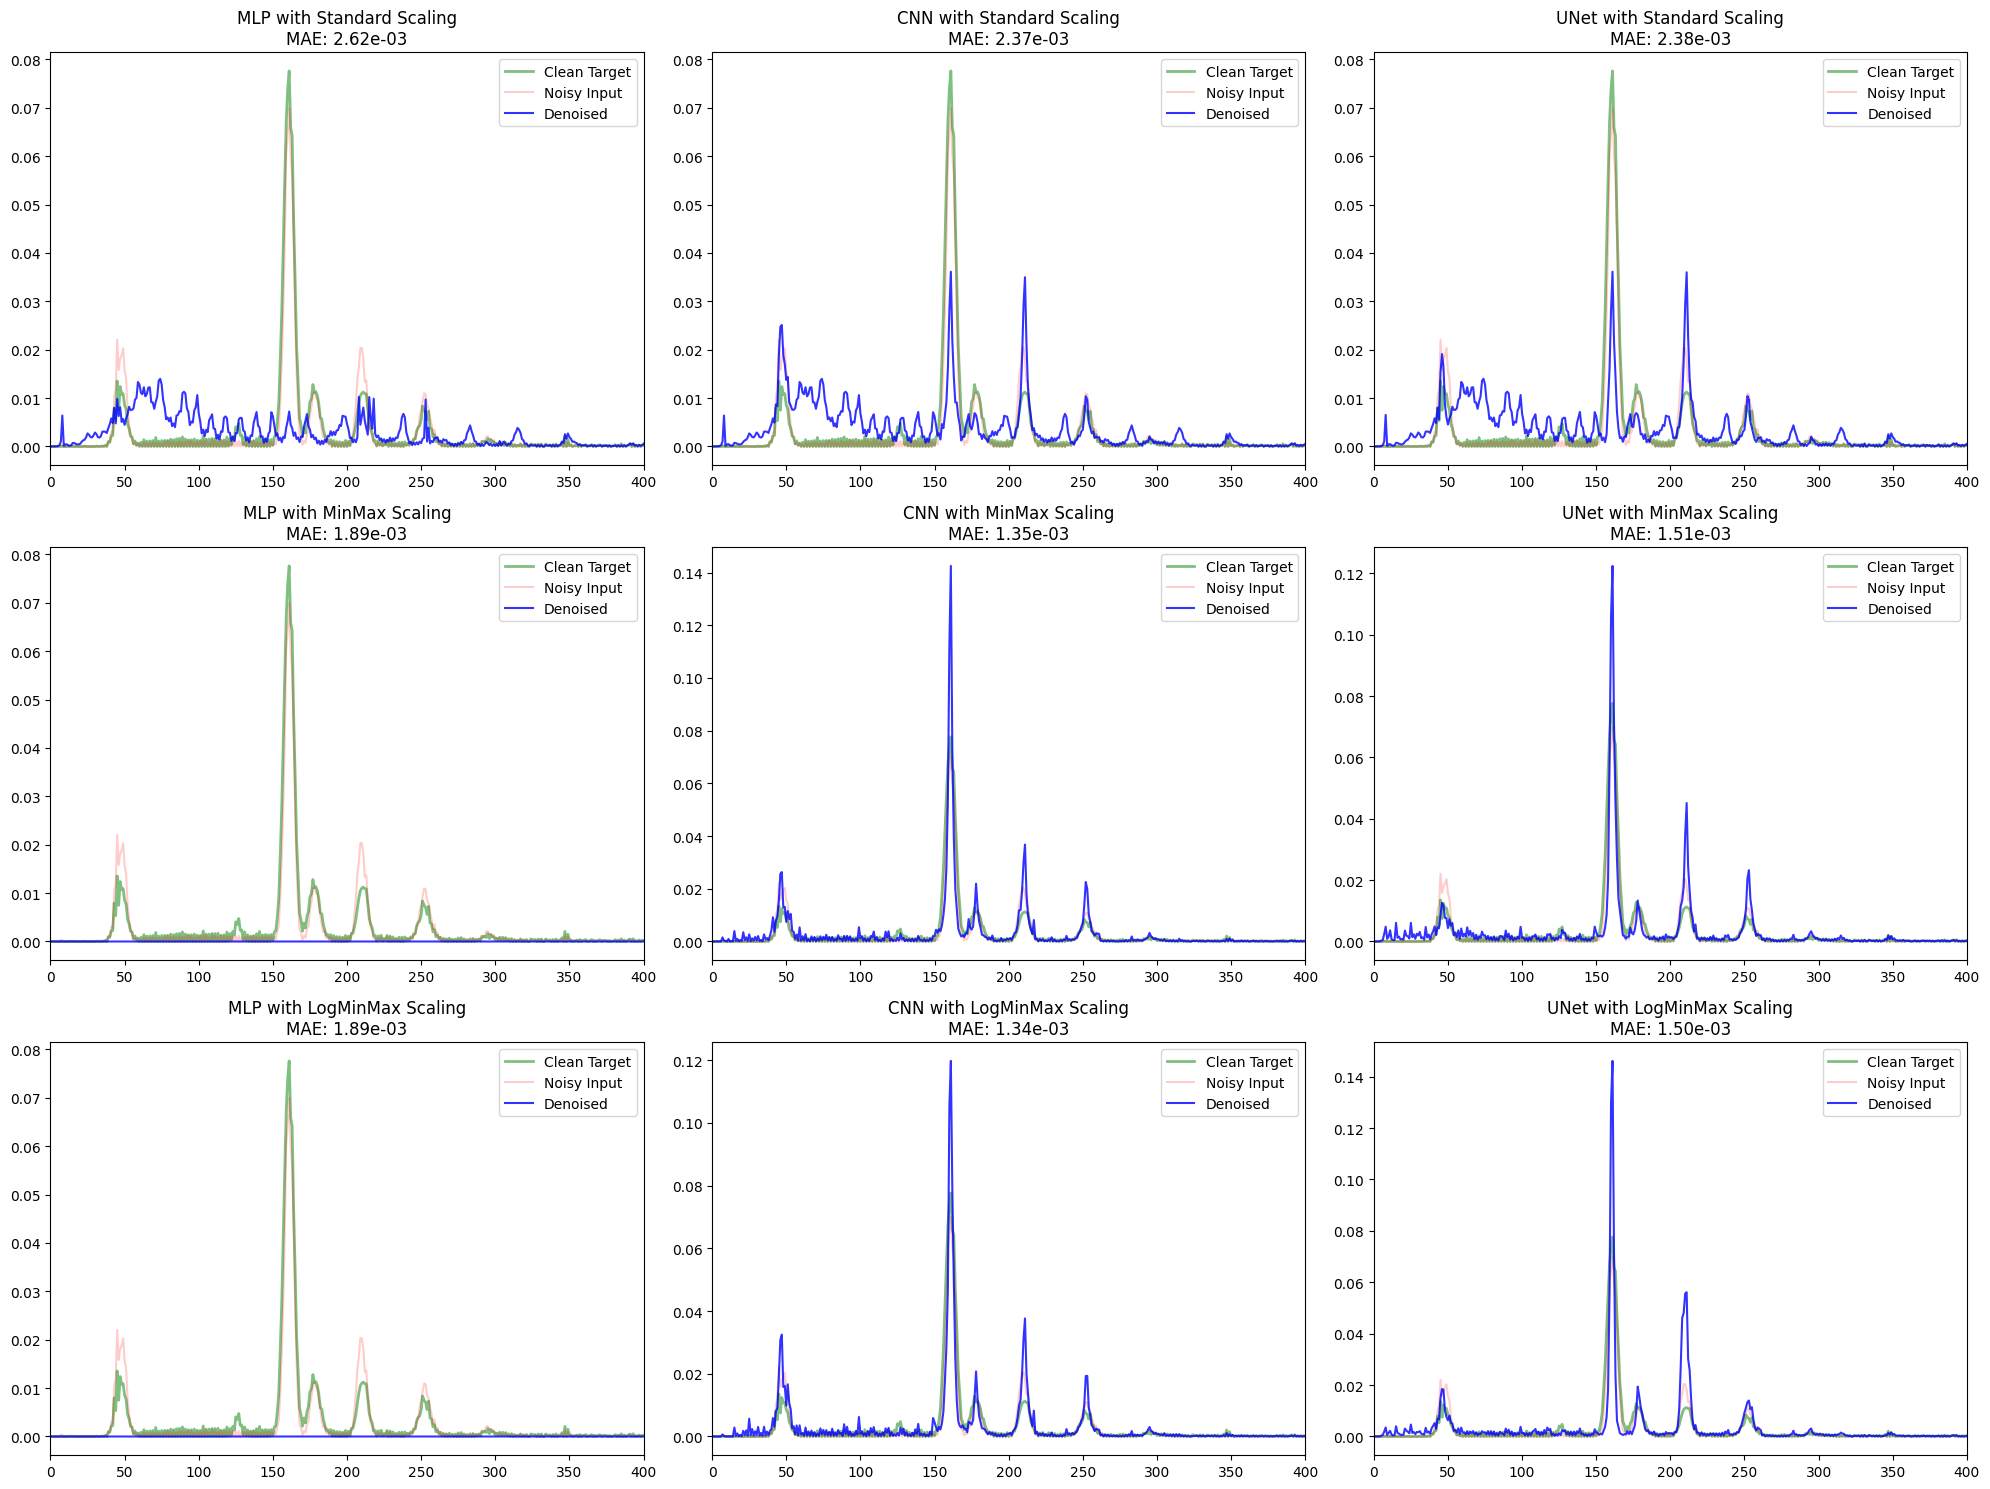

In [8]:
sample_idx = 0
test_noisy_sample = X_test_noisy[sample_idx:sample_idx+1]
test_clean_sample = y_test_clean[sample_idx:sample_idx+1]

plt.figure(figsize=(20, 15))

plot_idx = 1
for prep_name in preprocessing_strategies.keys():
    for arch_name in architectures.keys():
        key = f"{prep_name}_{arch_name}"
        trainer, scaler = trained_models[key]
        
        # Scale input, predict, inverse scale
        scaled_input = scaler.transform(test_noisy_sample)
        scaled_pred = trainer.predict(scaled_input)
        pred_orig = scaler.inverse_transform(scaled_pred)[0]
        
        plt.subplot(3, 3, plot_idx)
        plt.plot(test_clean_sample[0], label='Clean Target', color='green', alpha=0.5, lw=2)
        plt.plot(test_noisy_sample[0], label='Noisy Input', color='red', alpha=0.2)
        plt.plot(pred_orig, label='Denoised', color='blue', alpha=0.8)
        plt.title(f"{arch_name} with {prep_name} Scaling\nMAE: {results[key]['mae_orig']:.2e}")
        plt.legend()
        plt.xlim(0, 400) # Zoom in on the main peaks
        plot_idx += 1

plt.tight_layout()
plt.show()